# Practice Assignment 1: Linear Regression on Placement Data

## Objective:

This assignment helps you understand how Simple Linear Regression works using a dataset of
CGPA and placement package.

## Dataset Description:

1 cgpa → Student CGPA

2 package → Placement package in LPA

## Import necessary libraries

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

NameError: name 'model' is not defined

In [ ]:

df = pd.read_csv('placement.csv')

##  Display the first 5 rows

In [3]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


## Check the shape of the dataset

In [4]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (200, 2)


## Display the column names

In [5]:
print("\nColumn Names:", df.columns.tolist())


Column Names: ['cgpa', 'package']


## Check whether there are any missing values

In [6]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 cgpa       0
package    0
dtype: int64


## Show basic statistical summary of the dataset

In [7]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
             cgpa     package
count  200.000000  200.000000
mean     6.990500    2.996050
std      1.069409    0.691644
min      4.260000    1.370000
25%      6.190000    2.487500
50%      6.965000    2.995000
75%      7.737500    3.492500
max      9.580000    4.620000


## Create a scatter plot between CGPA and Package

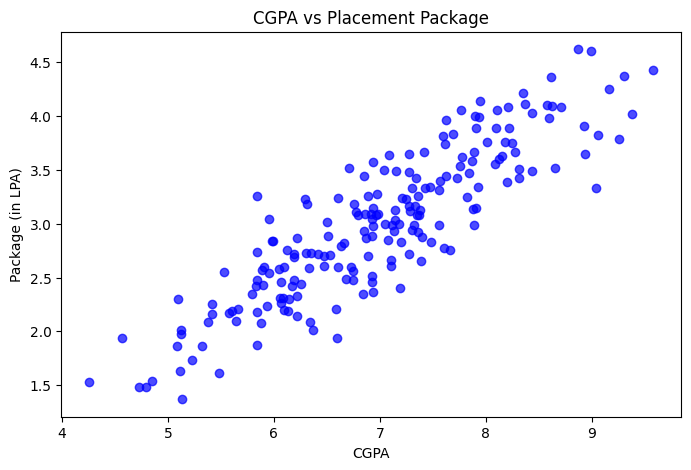

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df['cgpa'], df['package'], color='blue', alpha=0.7)
plt.xlabel('CGPA')
plt.ylabel('Package (in LPA)')
plt.title('CGPA vs Placement Package')
plt.show()

# 8. Observations
### Observation: There is a strong positive linear correlation between CGPA and Package. 
### As the CGPA increases, the package offered also tends to increase.
### The data points are closely clustered around a straight line path.

## Separate the dataset into X (cgpa) and y (package)

In [10]:
X = df[['cgpa']] # X must be 2D for sklearn
y = df['package']

##  Split the data into training set and testing set

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Import and train the Linear Regression model

In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Find slope (coefficient) and intercept

In [22]:
m = lr.coef_[0]
b = lr.intercept_
print(f"\nSlope (m): {m:.4f}")
print(f"Intercept (b): {b:.4f}")


Slope (m): 0.5763
Intercept (b): -1.0296


## Predict the package for CGPA = 8.5 and CGPA = 9.0

In [23]:
pred_85 = lr.predict(pd.DataFrame([[8.5]], columns=['cgpa']))
pred_90 = lr.predict(pd.DataFrame([[9.0]], columns=['cgpa']))

print(f"\nPredicted package for CGPA 8.5: {pred_85[0]:.2f} LPA")
print(f"Predicted package for CGPA 9.0: {pred_90[0]:.2f} LPA")


Predicted package for CGPA 8.5: 3.87 LPA
Predicted package for CGPA 9.0: 4.16 LPA


## Compare actual vs predicted values

In [24]:
y_pred = lr.predict(X_test)
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nActual vs Predicted Comparison (First 5 test samples):")
print(comparison_df.head())


Actual vs Predicted Comparison (First 5 test samples):
     Actual  Predicted
18     2.98   2.970126
170    2.87   2.555168
107    2.59   2.618565
98     3.83   3.402374
177    3.64   3.056576


## Plot the regression line on the scatter plot with labels/title

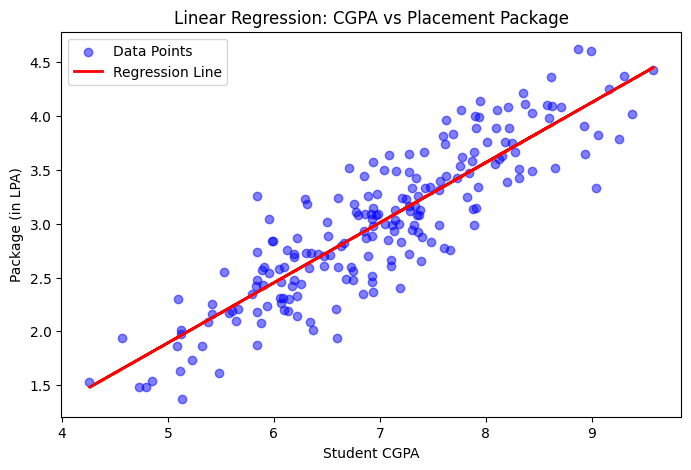

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(df['cgpa'], df['package'], color='blue', alpha=0.5, label='Data Points')
plt.plot(X_train, lr.predict(X_train), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Student CGPA')
plt.ylabel('Package (in LPA)')
plt.title('Linear Regression: CGPA vs Placement Package')
plt.legend()
plt.show()

## Write the regression equation

In [17]:
print(f"\nRegression Equation: y = {m:.2f}x + ({b:.2f})")



Regression Equation: y = 0.56x + (-0.90)


## Explanation

Meaning of Slope: The slope (m) represents the change in package for every 1 unit increase in CGPA. 
In this case, for every 1 point increase in CGPA, the package increases by roughly 0.56 LPA.

Meaning of Intercept: The intercept (b) is the theoretical package value if a student had a CGPA of 0. 
While not practically possible, it serves as the starting point for the line.

Is CGPA a good predictor? Yes. Looking at the scatter plot and the alignment of the regression line, 


# Model Accuracy

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 14.1 Calculate Model Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"\nModel Performance Metrics:")
print(f"R2 Score: {r2:.4f} (Approx {r2*100:.2f}%)")
print(f"Mean Absolute Error: {mae:.4f} LPA")
print(f"Mean Squared Error: {mse:.4f}")


Model Performance Metrics:
R2 Score: 0.7297 (Approx 72.97%)
Mean Absolute Error: 0.2552 LPA
Mean Squared Error: 0.1022


## 1. Mean Absolute Error (MAE)
The "Average Error"
What it is: It is the average of the absolute differences between the actual values and the predicted values.
The Math: It calculates |Actual - Predicted| for every point and finds the average.
In your project: If your MAE is 0.28, it means that on average, your model's prediction is off by 0.28 LPA (about ₹28,000).
Why use it? It is the easiest to understand because it is in the same unit as your output (LPA).

### 2. Mean Squared Error (MSE)
The "Punisher"
What it is: It calculates the difference between actual and predicted, squares it, and then finds the average.
The Math: (Actual - Predicted)² / number of points.
In your project: If a student’s actual package was 4.0 but you predicted 3.0, the error is 1.0. MSE squares that (1.0). If the error was 2.0, the square becomes 4.0.
Why use it? By squaring the error, MSE "punishes" large mistakes more than small ones. If your model makes a huge error on even one student, the MSE will jump up significantly. Data scientists use this to ensure the model doesn't have "outlier" errors.

## 3. R^2 Score (R-Squared)

 
The "Model Grade" (0 to 1)

What it is: Also known as the Coefficient of Determination. It tells you what percentage of the data's variation is explained by your model.
The Scale:
0: Your model is no better than just guessing the average package for everyone.
1: Your model is perfect (all points are exactly on the line).
In your project: If your 
R^2 is 0.78, it means that 78% of the variance in placement packages can be explained by the student's CGPA. The remaining 22% is likely due to other factors (like interview skills, internship experience, or luck).
Why use it? It is the most common way to describe the "Accuracy" of a regression model.